In [354]:
import os
import json
import pandas as pd
from typing import List

In [355]:
def load_parametres(subdir: str, filenames: List[str]) -> pd.DataFrame:
    rows = []
    for filename in filenames:
        path = f"{subdir}/{filename}"
        if os.path.exists(path):
            with open(path, 'r') as file:
                try:
                    data = json.load(file)
                except:
                    print(path)
        else:
            print(path)
            continue
        row = {}
        row['batch_size'] = data['data_size']
        row['num_microbatches'] = data['data_size'] // data['batch_size']
        row['prompt_len'] = data['max_prompt_len']
        row['new_tokens'] = data['max_new_tokens']
        row['time (s)'] = data['inference_time']
        row['throughput (tokens/s)'] = data['throughput']
        row['peak memory GPU:0'], row['peak memory GPU:1'], row['peak memory GPU:2'], row['peak memory GPU:3'] = data['max_memory_allocated_per_device']
        rows.append(row)
        
        
    return pd.DataFrame(rows)

filenames = []
for batch_size in [16, 24, 40]:
            # for num_microbatch in [1, 2, 4, 8]:
                filename = f"batch_size={batch_size}intern-6b_stats.json"
                filenames.append(filename)

df = load_parametres('src/results/intern/pipeline_1', filenames)  

src/results/intern/pipeline_1/batch_size=16intern-6b_stats.json
src/results/intern/pipeline_1/batch_size=24intern-6b_stats.json
src/results/intern/pipeline_1/batch_size=40intern-6b_stats.json


In [356]:
df.to_csv('intern-6b_pipeline_1.csv')

# Analyse

In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import string
from typing import List
import matplotlib.lines as mlines

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [ ]:
def plot_ratios_and_microbatches_decoder(
    df_1: pd.DataFrame,
    df_2: pd.DataFrame,
    gpus: List[str],
    batch_sizes: List[int] = None,
    new_tokens_list: List[int] = None,
    prompt_lens_list: List[int] = None,
    save_path: str = 'plot.svg',
    figsize_per_row: int = 5,
    bar_width_fraction: float = 0.8,
):

    # ── Параметры ──────────────────────────────────────────────────────────
    if batch_sizes is None:
        batch_sizes = range(8, 64 + 1, 8)
    batch_sizes = list(batch_sizes)

    if new_tokens_list is not None:
        new_tokens_list = list(new_tokens_list)
    if prompt_lens_list is not None:
        prompt_lens_list = list(prompt_lens_list)

    # ── Фильтрация ─────────────────────────────────────────────────────────
    df_1 = df_1.copy()
    df_2 = df_2.copy()

    if batch_sizes is not None:
        df_1 = df_1[df_1['batch_size'].isin(batch_sizes)]
        df_2 = df_2[df_2['batch_size'].isin(batch_sizes)]
    if new_tokens_list is not None:
        df_1 = df_1[df_1['new_tokens'].isin(new_tokens_list)]
        df_2 = df_2[df_2['new_tokens'].isin(new_tokens_list)]
    if prompt_lens_list is not None:
        df_1 = df_1[df_1['prompt_len'].isin(prompt_lens_list)]
        df_2 = df_2[df_2['prompt_len'].isin(prompt_lens_list)]

    df_1['max_gpu'] = df_1[gpus].max(axis=1)
    df_2['max_gpu'] = df_2[gpus].max(axis=1)

    n_rows = len(batch_sizes)
    n_subplots = n_rows * 3
    labels = list(string.ascii_lowercase[:n_subplots])

    plt.rcParams.update({
        'font.size': 18,
        'font.family': 'serif',
        'axes.titlesize': 20,   #  заголовки графиков
        'axes.labelsize': 18,   # подписи осей (Prompt length, Ratio)
        'xtick.labelsize': 16,  # числа на оси X
        'ytick.labelsize': 16,  # числа на оси Y
        'legend.fontsize': 18,  # легенда внизу
    })

    # ── Цвета ──────────────────────────────────────────────────────────────
    all_new_tokens = sorted(set(df_1['new_tokens']).union(df_2['new_tokens']))
    cmap_bars = sns.color_palette("colorblind", len(all_new_tokens))
    color_map = {nt: cmap_bars[i] for i, nt in enumerate(all_new_tokens)}

    unique_micro = sorted(df_2['num_microbatches'].unique())
    cmap_micro = ListedColormap(sns.color_palette("YlOrRd", len(unique_micro)))
    norm_micro = BoundaryNorm(
        boundaries=[v - 0.5 for v in unique_micro] + [unique_micro[-1] + 0.5],
        ncolors=len(unique_micro)
    )

    # ── Фигура ─────────────────────────────────────────────────────────────
    # Нижняя полоса: достаточно высокая, чтобы легенда не налезала на буквы.
    # Соотношение: основная сетка : нижняя полоса ≈ 1 : legend_ratio
    legend_ratio = 0.15

    fig = plt.figure(figsize=(24 , figsize_per_row * n_rows))

    outer = GridSpec(
        2, 1,
        figure=fig,
        # Добавляем пространство между основной сеткой и полосой легенды,
        # чтобы буква под последней строкой и легенда не пересекались.
        height_ratios=[1, legend_ratio / (1 - legend_ratio)],
        hspace=0.15,
    )

    # Основная сетка: 3 колонки данных, без отдельной колонки под colorbar
    inner = GridSpecFromSubplotSpec(
        n_rows, 3,
        subplot_spec=outer[0],
        width_ratios=[1.0, 1.0, 1.0],
        hspace=0.35,   # вертикальный зазор между строками
        wspace=0.2,
    )

    axes = np.empty((n_rows, 3), dtype=object)
    for i in range(n_rows):
        for j in range(3):
            axes[i, j] = fig.add_subplot(inner[i, j])

    # Нижняя ось для легенды
    ax_leg = fig.add_subplot(outer[1])
    ax_leg.axis('off')

    # ── Вспомогательная функция: grouped bar chart ─────────────────────────
    # letter_pad — насколько буква опущена ниже оси (в единицах transAxes).
    # Маленькое значение → буква ближе к графику.
    LETTER_PAD = -0.15

    def draw_grouped_bars(ax, ratio_pivot, title, ylabel, label):
        if ratio_pivot is None or ratio_pivot.empty:
            ax.axis('off')
            return
    
        pl      = ratio_pivot.index.values
        nt_cols = ratio_pivot.columns.values
        x = np.arange(len(pl))
        single_width = bar_width_fraction / len(nt_cols)
    
        all_bars = {}  # (xi, j) -> (bar, val)
    
        for j, nt in enumerate(nt_cols):
            offset = (j - len(nt_cols) / 2 + 0.5) * single_width
            vals   = ratio_pivot[nt].values
            bars   = ax.bar(
                x + offset, vals, single_width,
                color=color_map[nt], label=f'output tokens={nt}', alpha=0.85
            )
            for xi, (bar, val) in enumerate(zip(bars, vals)):
                all_bars[(xi, j)] = (bar, val)
    
        # Подпись максимума по центру группы
        for xi in range(len(pl)):
            group_vals = {j: all_bars[(xi, j)][1] for j in range(len(nt_cols))}
            max_j = max(group_vals, key=group_vals.get)
            max_val = group_vals[max_j]
    
            # Центр группы — это просто x[xi], высота — максимальное значение
            ax.text(
                x[xi], max_val,
                f"{max_val:.2f}", ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black',
            )
    
        ax.axhline(1.0, linestyle='--', color='red')
        ax.set_xticks(x)
        ax.set_xticklabels(pl)
        ax.set_xlabel("Prompt length")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)
    
        ax.text(
            0.5, LETTER_PAD, f'{label}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=18, fontstyle='italic', fontweight='bold',
        )

    # ── Основной цикл ──────────────────────────────────────────────────────
    for i, bs in enumerate(batch_sizes):
        data1 = df_1[df_1['batch_size'] == bs]
        data2 = df_2[df_2['batch_size'] == bs]
        if data1.empty or data2.empty:
            continue

        pivot1_thr = data1.pivot_table(values='throughput (tokens/s)',
                                       index='prompt_len', columns='new_tokens')
        pivot1_mem = data1.pivot_table(values='max_gpu',
                                       index='prompt_len', columns='new_tokens')

        best_idx   = (data2.groupby(['prompt_len', 'new_tokens'])
                          ['throughput (tokens/s)'].idxmax())
        best_data2 = data2.loc[best_idx]

        pivot2_thr  = best_data2.pivot_table(values='throughput (tokens/s)',
                                              index='prompt_len', columns='new_tokens')
        pivot2_mem  = best_data2.pivot_table(values='max_gpu',
                                              index='prompt_len', columns='new_tokens')
        pivot_micro = best_data2.pivot_table(values='num_microbatches',
                                              index='prompt_len', columns='new_tokens')

        ratio_thr = pivot2_thr / pivot1_thr
        ratio_mem = pivot2_mem / pivot1_mem

        lbl_thr   = labels[i * 3]
        lbl_mem   = labels[i * 3 + 1]
        lbl_micro = labels[i * 3 + 2]

        draw_grouped_bars(axes[i, 0], ratio_thr,
                          f"Throughput | batch size={bs}", "Ratio", lbl_thr)
        draw_grouped_bars(axes[i, 1], ratio_mem,
                          f"Memory | batch size={bs}", "Ratio", lbl_mem)

        sns.heatmap(
            pivot_micro,
            annot=True, fmt='.0f',
            cmap=cmap_micro, norm=norm_micro,
            ax=axes[i, 2],
            linewidths=1, linecolor='white',
            cbar=False,
        )
        axes[i, 2].set_title(f"Microbatches | batch size={bs}")
        axes[i, 2].set_xlabel("Output tokens")
        axes[i, 2].set_ylabel("Prompt length")

        axes[i, 2].text(
            0.5, LETTER_PAD, f'{lbl_micro}',
            transform=axes[i, 2].transAxes,
            ha='center', va='top',
            fontsize=18, fontstyle='italic', fontweight='bold',
        )

    # ── Нижняя легенда ─────────────────────────────────────────────────────
    bar_handles = [
        mpatches.Patch(facecolor=color_map[nt], label=f'output tokens = {nt}', alpha=0.85)
        for nt in all_new_tokens
    ]

    ax_leg.legend(
        handles=bar_handles,
        loc='upper center',          # прижимаем к верху полосы легенды,
        ncol=len(all_new_tokens),    # чтобы не слипаться с буквами
        title='Output tokens',
        title_fontsize=20,
        fontsize=18,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        borderpad=1.0,
        labelspacing=0.7,
        handlelength=1.8,
        handleheight=1.4,
        columnspacing=1.5,
    )

    plt.savefig(save_path, format='pdf')
    plt.show()
    print(f"Saved to {save_path}")

## OPT-1.3B

In [359]:
df_1 = pd.read_csv("src/results/opt/opt-1.3b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-1.3b_pipeline_2.csv")

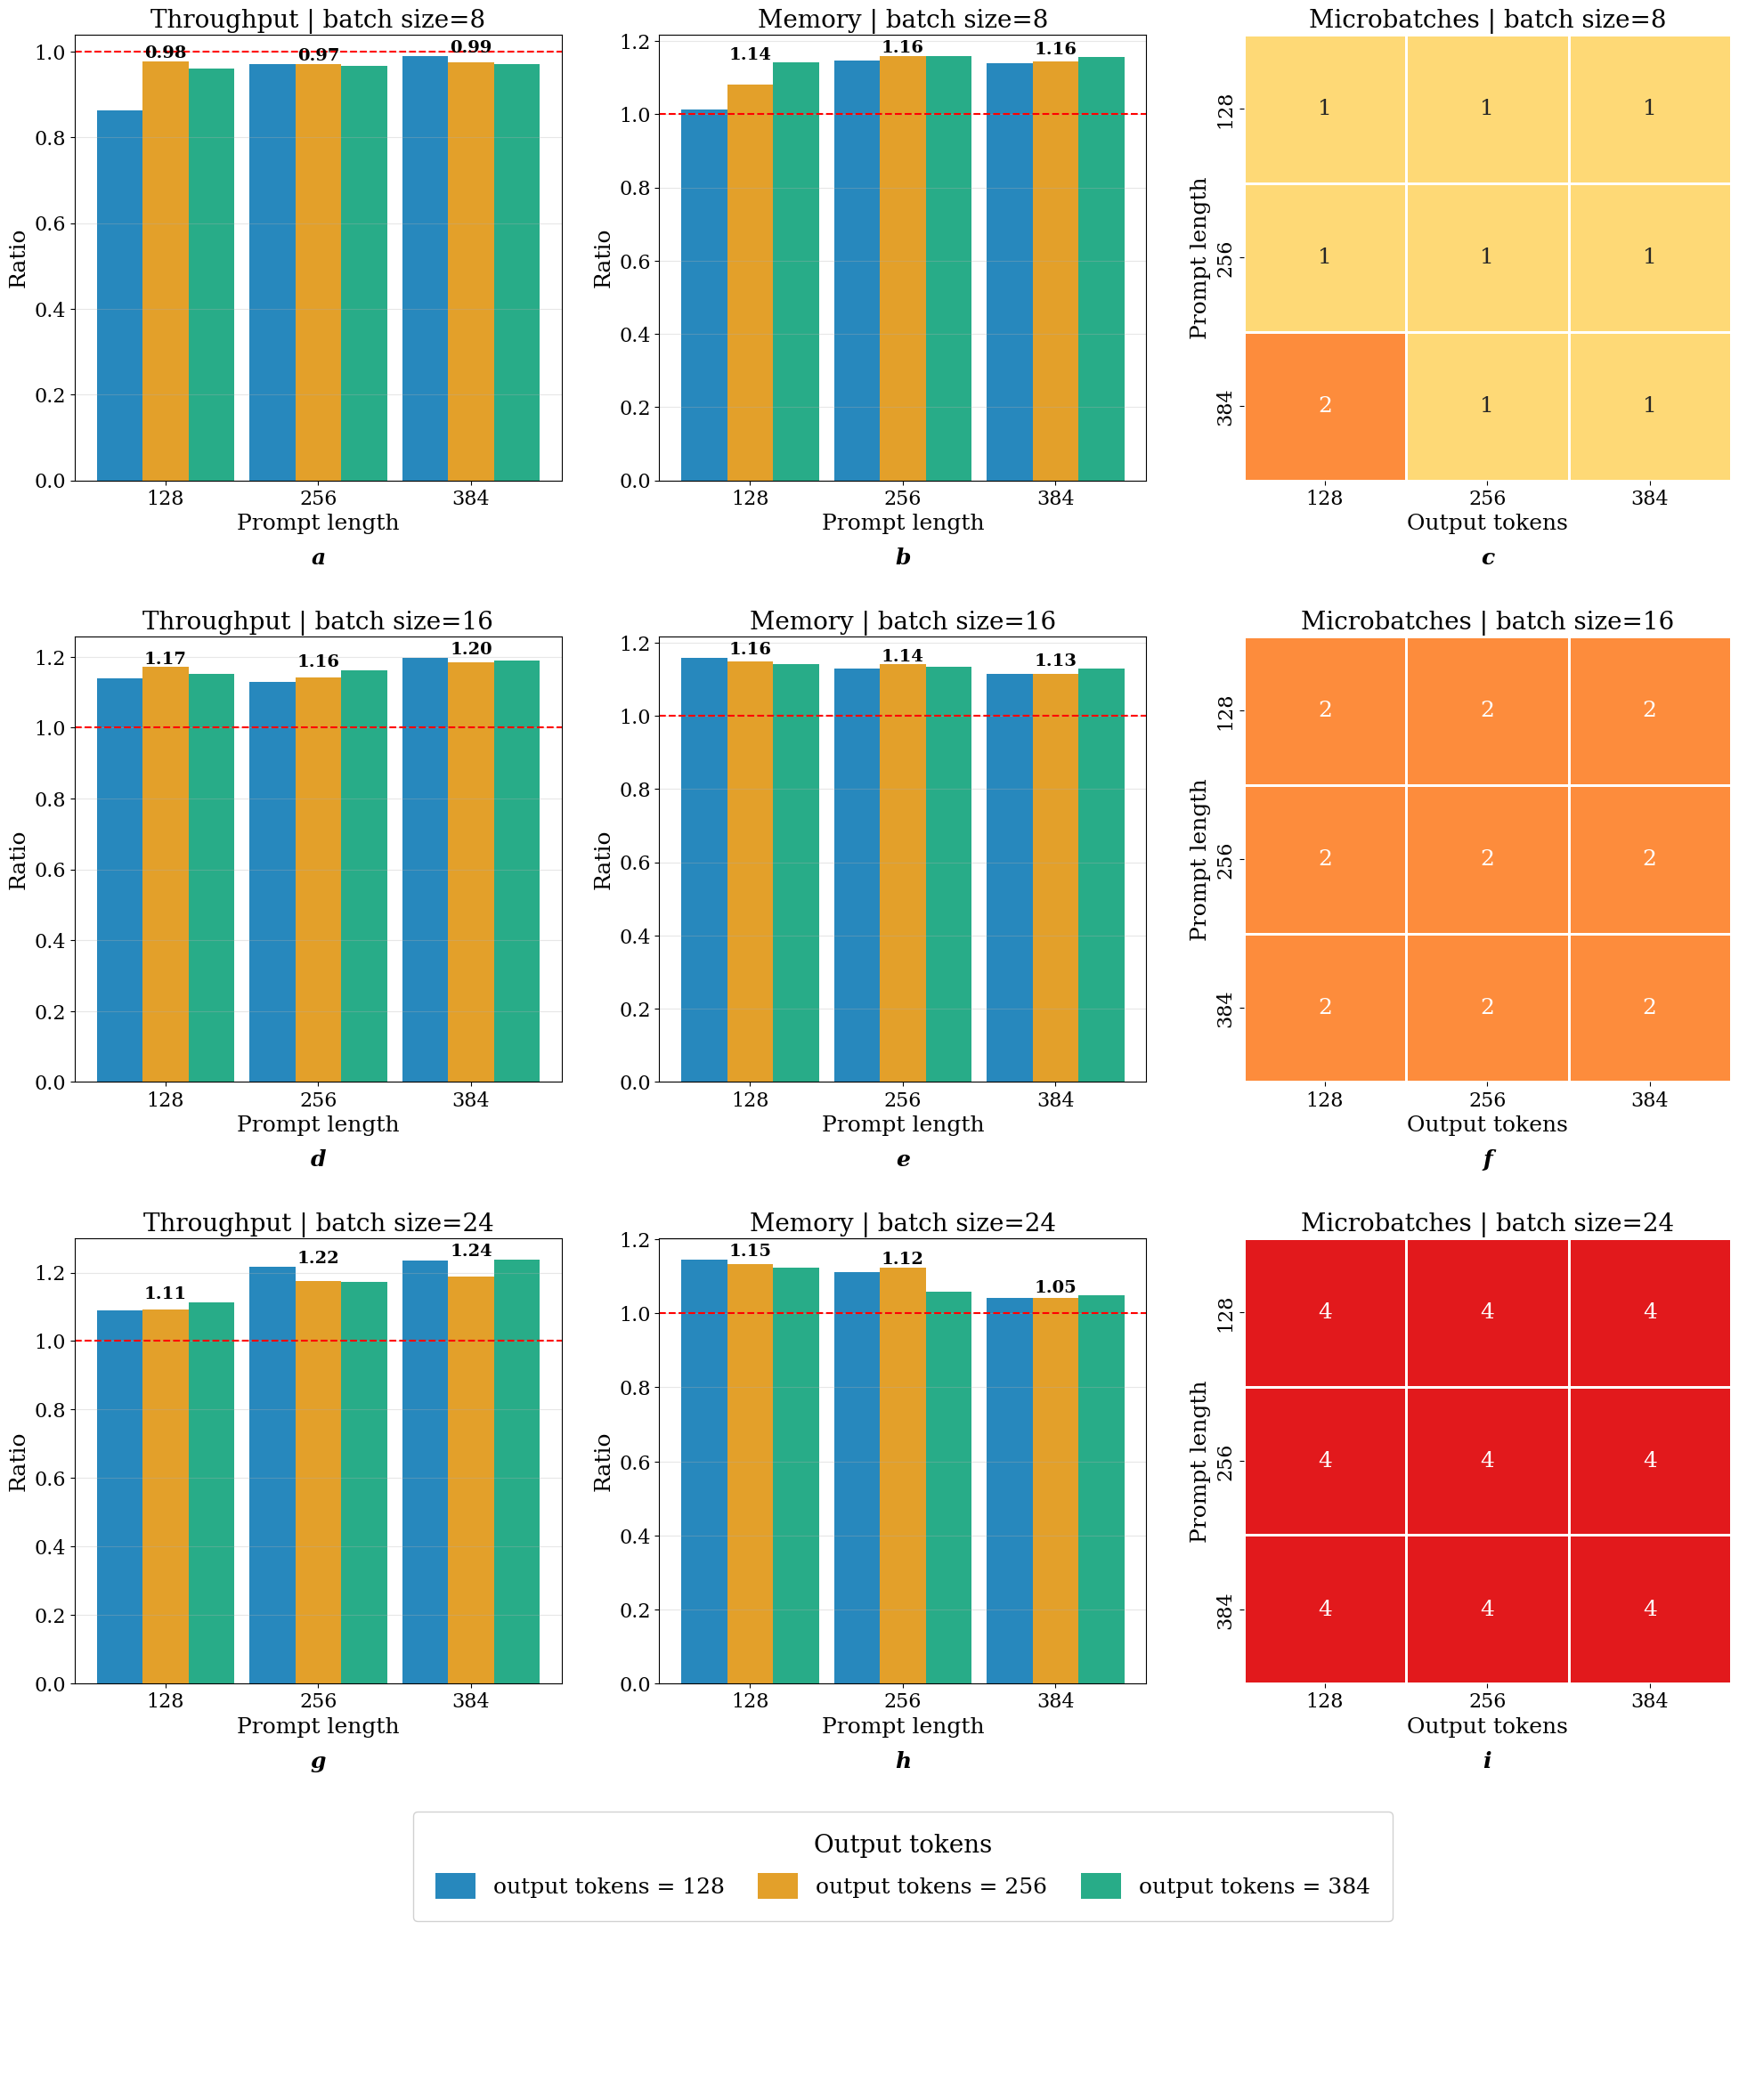

Saved to opt-1.3b.pdf


In [360]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16, 24],
                             prompt_lens_list=[128, 256, 384],
                             new_tokens_list=[128, 256, 384],
                             figsize_per_row=10, 
                             bar_width_fraction=0.9,
                             save_path="opt-1.3b.pdf")

**Задачи:**
1. Провести эксперимент с Deepspeed и transformers
2. провести эксперимент с batch_size = 16, но более большим new_tokens и prompt_len

### opt-1.3b-prefill

In [361]:
df_1 = pd.read_csv("src/results/opt/opt-1.3b-prefill_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-1.3b-prefill_pipeline_2.csv")

In [362]:
def plot_ratios_and_microbatches_encoder(
    df_1: pd.DataFrame,
    df_2: pd.DataFrame,
    gpus: List[str],
    batch_sizes: List[int] = None,
    prompt_lens_list: List[int] = None,
    save_path: str = 'plot.svg',
    figsize_per_row: int = 5,
):
    # ── Фильтрация ─────────────────────────────────────────────────────────
    df_1 = df_1.copy()
    df_2 = df_2.copy()

    if batch_sizes is not None:
        df_1 = df_1[df_1['batch_size'].isin(batch_sizes)]
        df_2 = df_2[df_2['batch_size'].isin(batch_sizes)]
    if prompt_lens_list is not None:
        df_1 = df_1[df_1['prompt_len'].isin(prompt_lens_list)]
        df_2 = df_2[df_2['prompt_len'].isin(prompt_lens_list)]

    df_1['max_gpu'] = df_1[gpus].max(axis=1)

    # ── Лучший df_2 по throughput ──────────────────────────────────────────
    best_idx   = df_2.groupby(['prompt_len', 'batch_size'])['throughput (tokens/s)'].idxmax()
    best_data2 = df_2.loc[best_idx].copy()
    best_data2['max_gpu'] = best_data2[gpus].max(axis=1)

    # ── Pivot tables ───────────────────────────────────────────────────────
    pivot_thr      = best_data2.pivot_table(values='throughput (tokens/s)',
                                            index='prompt_len', columns='batch_size')
    pivot_thr_base = df_1.pivot_table(values='throughput (tokens/s)',
                                      index='prompt_len', columns='batch_size')
    pivot_mem      = best_data2.pivot_table(values='max_gpu',
                                            index='prompt_len', columns='batch_size')
    pivot_mem_base = df_1.pivot_table(values='max_gpu',
                                      index='prompt_len', columns='batch_size')
    pivot_micro    = best_data2.pivot_table(values='num_microbatches',
                                            index='prompt_len', columns='batch_size')

    ratio_thr = pivot_thr / pivot_thr_base
    ratio_mem = pivot_mem / pivot_mem_base

    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)

    all_batch_sizes = sorted(ratio_thr.columns.tolist())

    # ── Стиль ─────────────────────────────────────────────────────────────
    plt.rcParams.update({
        'font.size': 18,
        'font.family': 'serif',
        'axes.titlesize': 18,
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 18,
    })

    cmap_lines = sns.color_palette("colorblind", len(all_batch_sizes))
    color_map  = {bs: cmap_lines[i] for i, bs in enumerate(all_batch_sizes)}
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    marker_map = {bs: markers[i % len(markers)] for i, bs in enumerate(all_batch_sizes)}

    # ── Фигура: основная сетка (1×3) + нижняя полоса легенды ──────────────
    LETTER_PAD  = -0.18
    legend_ratio = 0.10

    fig = plt.figure(figsize=(24, figsize_per_row))

    outer = GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[1, legend_ratio / (1 - legend_ratio)],
        hspace=0.45,
    )
    inner = GridSpecFromSubplotSpec(
        1, 3,
        subplot_spec=outer[0],
        width_ratios=[1.0, 1.0, 1.0],
        wspace=0.20,
    )

    ax_thr   = fig.add_subplot(inner[0, 0])
    ax_mem   = fig.add_subplot(inner[0, 1])
    ax_micro = fig.add_subplot(inner[0, 2])
    ax_leg   = fig.add_subplot(outer[1])
    ax_leg.axis('off')

    # ── Вспомогательная: line plot ─────────────────────────────────────────
    def draw_line_plot(ax, ratio_pivot, title, ylabel, label, mean_val):
        prompt_lens = ratio_pivot.index.values
        for bs in all_batch_sizes:
            if bs not in ratio_pivot.columns:
                continue
            vals = ratio_pivot[bs].values
            ax.plot(
                prompt_lens, vals,
                color=color_map[bs],
                marker=marker_map[bs],
                linewidth=1.8,
                markersize=6,
                label=f'batch size = {bs}',
            )
        ax.axhline(1.0, linestyle='--', color='red')
        ax.set_xlabel("Prompt length")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title}")
        ax.set_xticks(prompt_lens)
        ax.grid(axis='y', alpha=0.8, linestyle='--', linewidth=0.8)
        ax.grid(axis='x', alpha=0.8, linestyle='--', linewidth=0.8)

        ax.text(
            0.5, LETTER_PAD, f'{label}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=18, fontstyle='italic', fontweight='bold',
        )

    # ── Line plots ─────────────────────────────────────────────────────────
    draw_line_plot(ax_thr,  ratio_thr, "Throughput ratio", "Ratio", 'a', mean_ratio_thr)
    draw_line_plot(ax_mem,  ratio_mem, "Memory ratio",     "Ratio", 'b', mean_ratio_mem)

    # ── Heatmap ────────────────────────────────────────────────────────────
    unique_micro = sorted(best_data2['num_microbatches'].unique())
    cmap_micro   = ListedColormap(sns.color_palette("YlOrRd", len(unique_micro)))
    norm_micro   = BoundaryNorm(
        boundaries=[v - 0.5 for v in unique_micro] + [unique_micro[-1] + 0.5],
        ncolors=len(unique_micro)
    )

    sns.heatmap(
        pivot_micro,
        annot=True, fmt='.0f',
        cmap=cmap_micro, norm=norm_micro,
        ax=ax_micro,
        linewidths=1, linecolor='white',
        cbar=False,
    )

    ax_micro.set_title("Optimal num microbatches")
    ax_micro.set_xlabel("batch size")
    ax_micro.set_ylabel("prompt len")

    ax_micro.text(
        0.5, LETTER_PAD, 'c',
        transform=ax_micro.transAxes,
        ha='center', va='top',
        fontsize=18, fontstyle='italic', fontweight='bold',
    )

    # ── Нижняя легенда ─────────────────────────────────────────────────────
    line_handles = [
        mlines.Line2D(
            [], [],
            color=color_map[bs],
            marker=marker_map[bs],
            linewidth=1.8,
            markersize=7,
            label=f'batch size = {bs}',
        )
        for bs in all_batch_sizes
    ]

    ax_leg.legend(
        handles=line_handles,
        loc='upper center',
        ncol=len(all_batch_sizes),
        title='Batch size',
        title_fontsize=20,
        fontsize=19,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        borderpad=1.0,
        labelspacing=0.7,
        handlelength=2.0,
        handleheight=1.4,
        columnspacing=1.5,
    )

    plt.savefig(save_path, format='pdf')
    plt.show()
    print(f"Saved to {save_path}")

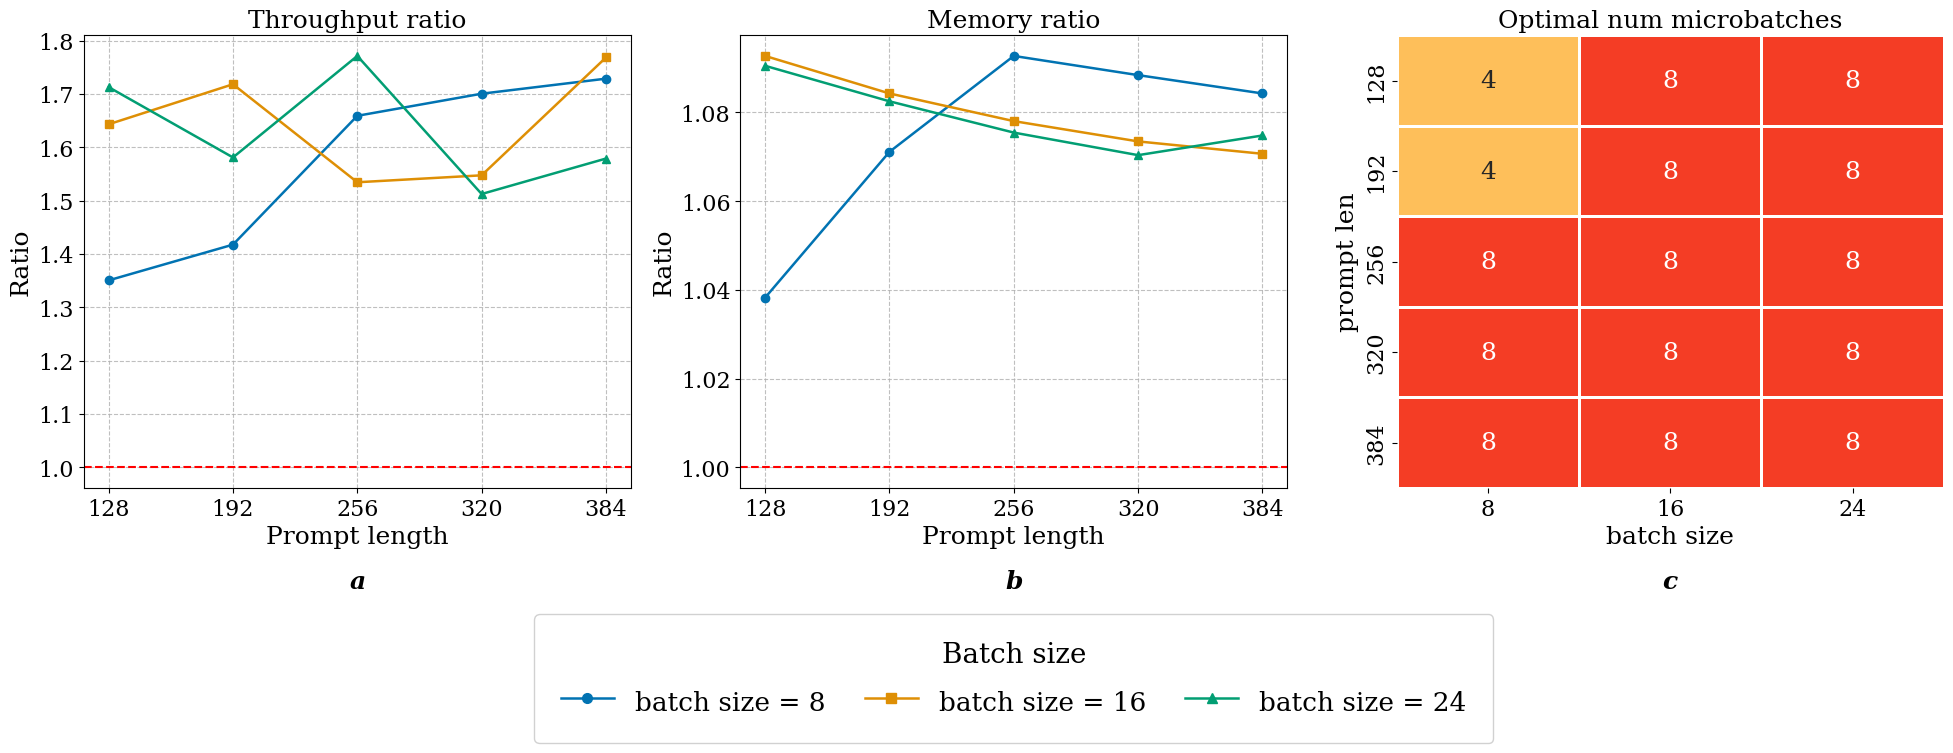

Saved to opt-1.3b-prefill.pdf


In [363]:
plot_ratios_and_microbatches_encoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16, 24],
                             prompt_lens_list=[128, 192, 256, 320, 384],
                             figsize_per_row=8,
                             save_path="opt-1.3b-prefill.pdf")

## Deberta

In [364]:
df_1 = pd.read_csv("src/results/deberta/deberta_pipeline_1.csv")
df_2 = pd.read_csv("src/results/deberta/deberta_pipeline_2.csv")

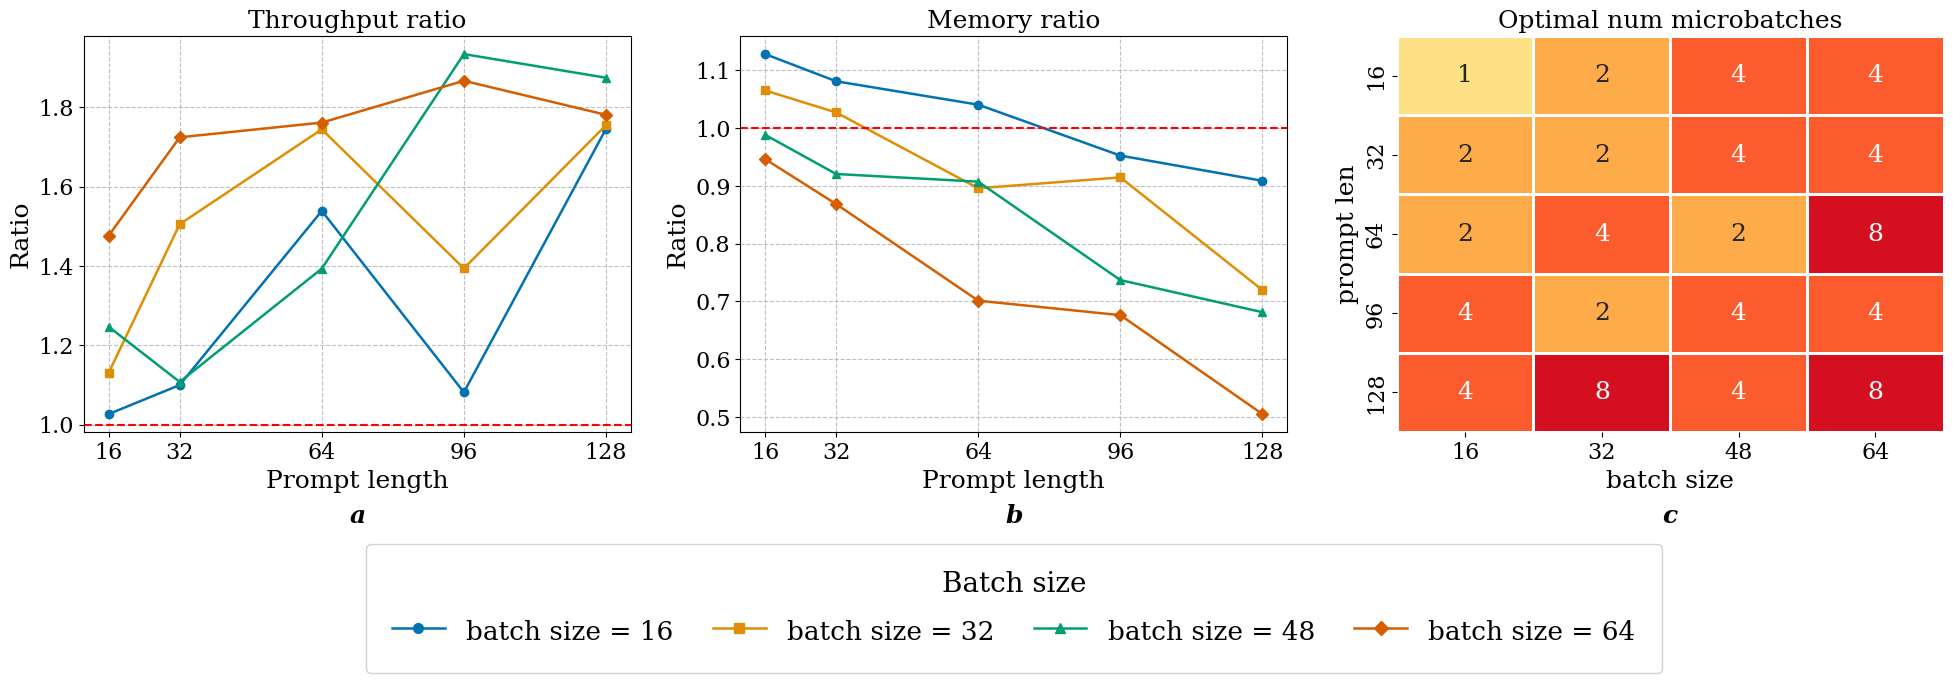

Saved to deberta.pdf


In [365]:
plot_ratios_and_microbatches_encoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[16, 32, 48, 64],
                             prompt_lens_list=[16, 32, 64, 96, 128],
                             figsize_per_row=7,
                             save_path="deberta.pdf")

## VIT-Giant(DinoV2)

In [366]:
df_1 = pd.read_csv("src/results/dinov2/dinov2_pipeline_1.csv")
df_2 = pd.read_csv("src/results/dinov2/dinov2_pipeline_2.csv")

In [367]:
def plot_ratios_and_microbatches_vit(
    df_1: pd.DataFrame,
    df_2: pd.DataFrame,
    gpus: List[str],
    batch_sizes: List[int] = None,
    save_path: str = 'plot.svg',
    figsize_per_row: int = 6,
):
    # ── Фильтрация ─────────────────────────────────────────────────────────
    df_1 = df_1.copy()
    df_2 = df_2.copy()

    if batch_sizes is not None:
        df_1 = df_1[df_1['batch_size'].isin(batch_sizes)]
        df_2 = df_2[df_2['batch_size'].isin(batch_sizes)]
    df_1['max_gpu'] = df_1[gpus].max(axis=1)
    df_2['max_gpu'] = df_2[gpus].max(axis=1)

    # ── Агрегация df_1 (baseline) ──────────────────────────────────────────
    df1_group = df_1.groupby(['batch_size']).mean(numeric_only=True).reset_index()

    # ── Лучший df_2 по throughput, затем группировка ──────────────────────
    best_idx   = df_2.groupby(['batch_size', 'num_microbatches'])['throughput (tokens/s)'].idxmax()
    best_data2 = df_2.loc[best_idx].copy()
    df2_group  = best_data2.groupby(['batch_size', 'num_microbatches']).mean(numeric_only=True).reset_index()

    # ── Pivot tables ───────────────────────────────────────────────────────
    pivot_thr = df2_group.pivot_table(
        values='throughput (tokens/s)',
        index='num_microbatches',
        columns='batch_size',
    )
    pivot_mem = df2_group.pivot_table(
        values='max_gpu',
        index='num_microbatches',
        columns='batch_size',
    )

    pivot_thr_base = df1_group.set_index('batch_size')['throughput (tokens/s)']
    pivot_mem_base = df1_group.set_index('batch_size')['max_gpu']

    # Broadcast baseline по строкам (num_microbatches)
    pivot_thr_base = pd.DataFrame(
        [pivot_thr_base] * len(pivot_thr.index),
        index=pivot_thr.index,
        columns=pivot_thr_base.index,
    )
    pivot_mem_base = pd.DataFrame(
        [pivot_mem_base] * len(pivot_mem.index),
        index=pivot_mem.index,
        columns=pivot_mem_base.index,
    )

    ratio_thr = pivot_thr / pivot_thr_base
    ratio_mem = pivot_mem / pivot_mem_base

    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)

    all_batch_sizes  = sorted(ratio_thr.columns.tolist())
    all_microbatches = sorted(ratio_thr.index.tolist())

    # ── Стиль ─────────────────────────────────────────────────────────────
    plt.rcParams.update({
        'font.size': 18,
        'font.family': 'serif',
        'axes.titlesize': 18,
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 18,
    })

    cmap_lines = sns.color_palette("colorblind", len(all_microbatches))
    color_map  = {mb: cmap_lines[i] for i, mb in enumerate(all_microbatches)}
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    marker_map = {mb: markers[i % len(markers)] for i, mb in enumerate(all_microbatches)}

    # ── Фигура: основная сетка (1×2) + нижняя полоса легенды ──────────────
    LETTER_PAD   = -0.18
    legend_ratio = 0.10

    fig = plt.figure(figsize=(16, figsize_per_row))

    outer = GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[1, legend_ratio / (1 - legend_ratio)],
        hspace=0.45,
    )
    inner = GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=outer[0],
        wspace=0.15,
    )

    ax_thr = fig.add_subplot(inner[0, 0])
    ax_mem = fig.add_subplot(inner[0, 1])
    ax_leg = fig.add_subplot(outer[1])
    ax_leg.axis('off')

    # ── Вспомогательная: line plot ─────────────────────────────────────────
    def draw_line_plot(ax, ratio_pivot, title, ylabel, label, mean_val):
        # ratio_pivot: index=num_microbatches, columns=batch_size
        # Нам нужно: x=batch_size, линия=num_microbatches
        # → транспонируем для удобства итерации
        for mb in all_microbatches:
            if mb not in ratio_pivot.index:
                continue
            vals = ratio_pivot.loc[mb, all_batch_sizes].values
            ax.plot(
                all_batch_sizes, vals,
                color=color_map[mb],
                marker=marker_map[mb],
                linewidth=1.8,
                markersize=6,
                label=f'num microbatches = {mb}',
            )
        ax.axhline(1.0, linestyle='--', color='red')
        ax.set_xlabel("Batch size")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title}")
        ax.set_xticks(all_batch_sizes)
        ax.grid(axis='y', alpha=0.8, linestyle='--', linewidth=0.8)
        ax.grid(axis='x', alpha=0.8, linestyle='--', linewidth=0.8)

        ax.text(
            0.5, LETTER_PAD, f'{label}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=13, fontstyle='italic', fontweight='bold',
        )

    # ── Line plots ─────────────────────────────────────────────────────────
    draw_line_plot(ax_thr, ratio_thr, "Throughput ratio", "Ratio", 'a', mean_ratio_thr)
    draw_line_plot(ax_mem, ratio_mem, "Memory ratio",     "Ratio", 'b', mean_ratio_mem)

    # ── Нижняя легенда ─────────────────────────────────────────────────────
    line_handles = [
        mlines.Line2D(
            [], [],
            color=color_map[mb],
            marker=marker_map[mb],
            linewidth=1.8,
            markersize=7,
            label=f'num microbatches = {mb}',
        )
        for mb in all_microbatches
    ]

    ax_leg.legend(
        handles=line_handles,
        loc='upper center',
        ncol=len(all_microbatches),
        title='Num microbatches',
        title_fontsize=15,
        fontsize=14,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        borderpad=1.0,
        labelspacing=0.7,
        handlelength=2.0,
        handleheight=1.4,
        columnspacing=1.5,
    )

    plt.savefig(save_path, format='pdf')
    plt.show()
    print(f"Saved to {save_path}")

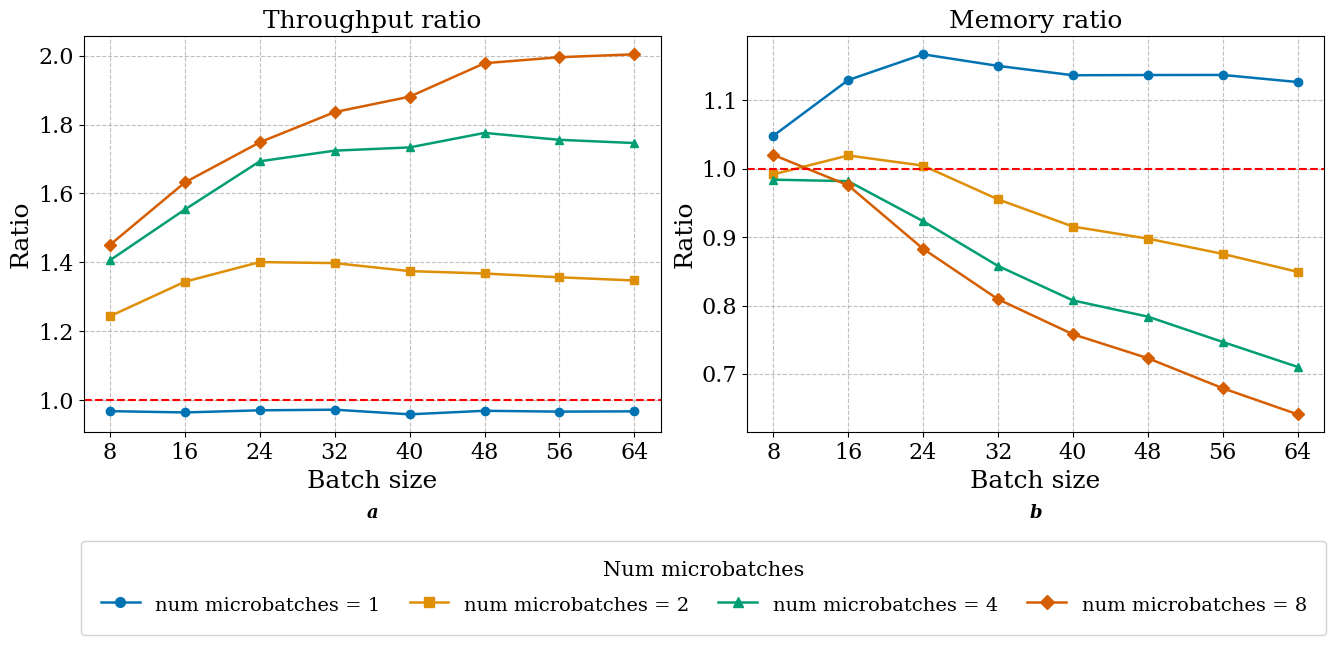

Saved to dinov2.pdf


In [368]:
plot_ratios_and_microbatches_vit(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             figsize_per_row=7,
                             save_path="dinov2.pdf")

## Bloom-3B

In [369]:
df_1 = pd.read_csv("src/results/bloom/bloom-3b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/bloom/bloom-3b_pipeline_2.csv")

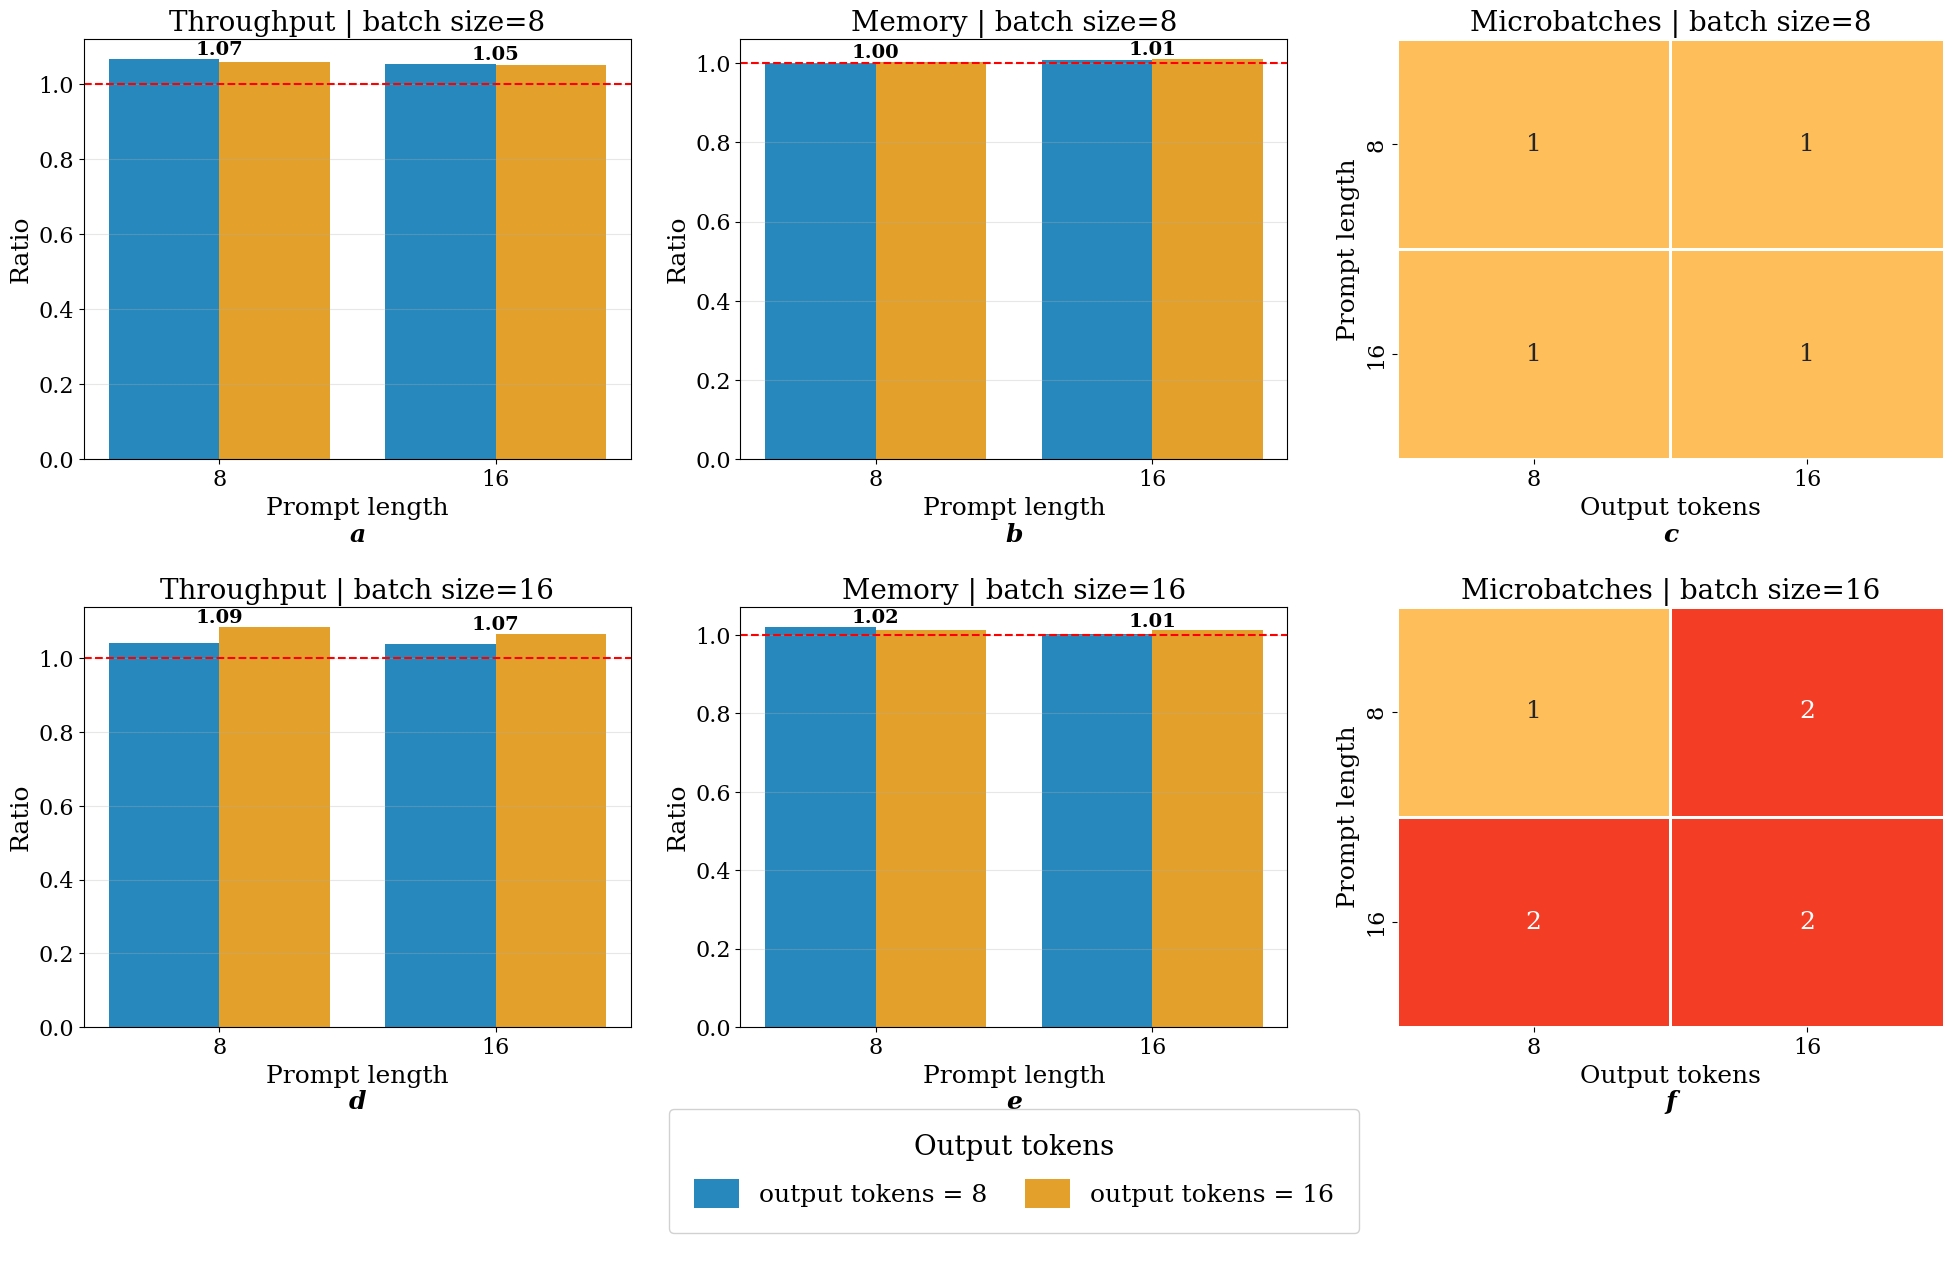

Saved to bloom-3b.pdf


In [370]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             gpus=['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16],
                             prompt_lens_list=[8, 16],
                             new_tokens_list=[8, 16],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="bloom-3b.pdf")

## OPT-2.7B

In [371]:
df_1 = pd.read_csv("src/results/opt/opt-2.7b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-2.7b_pipeline_2.csv")

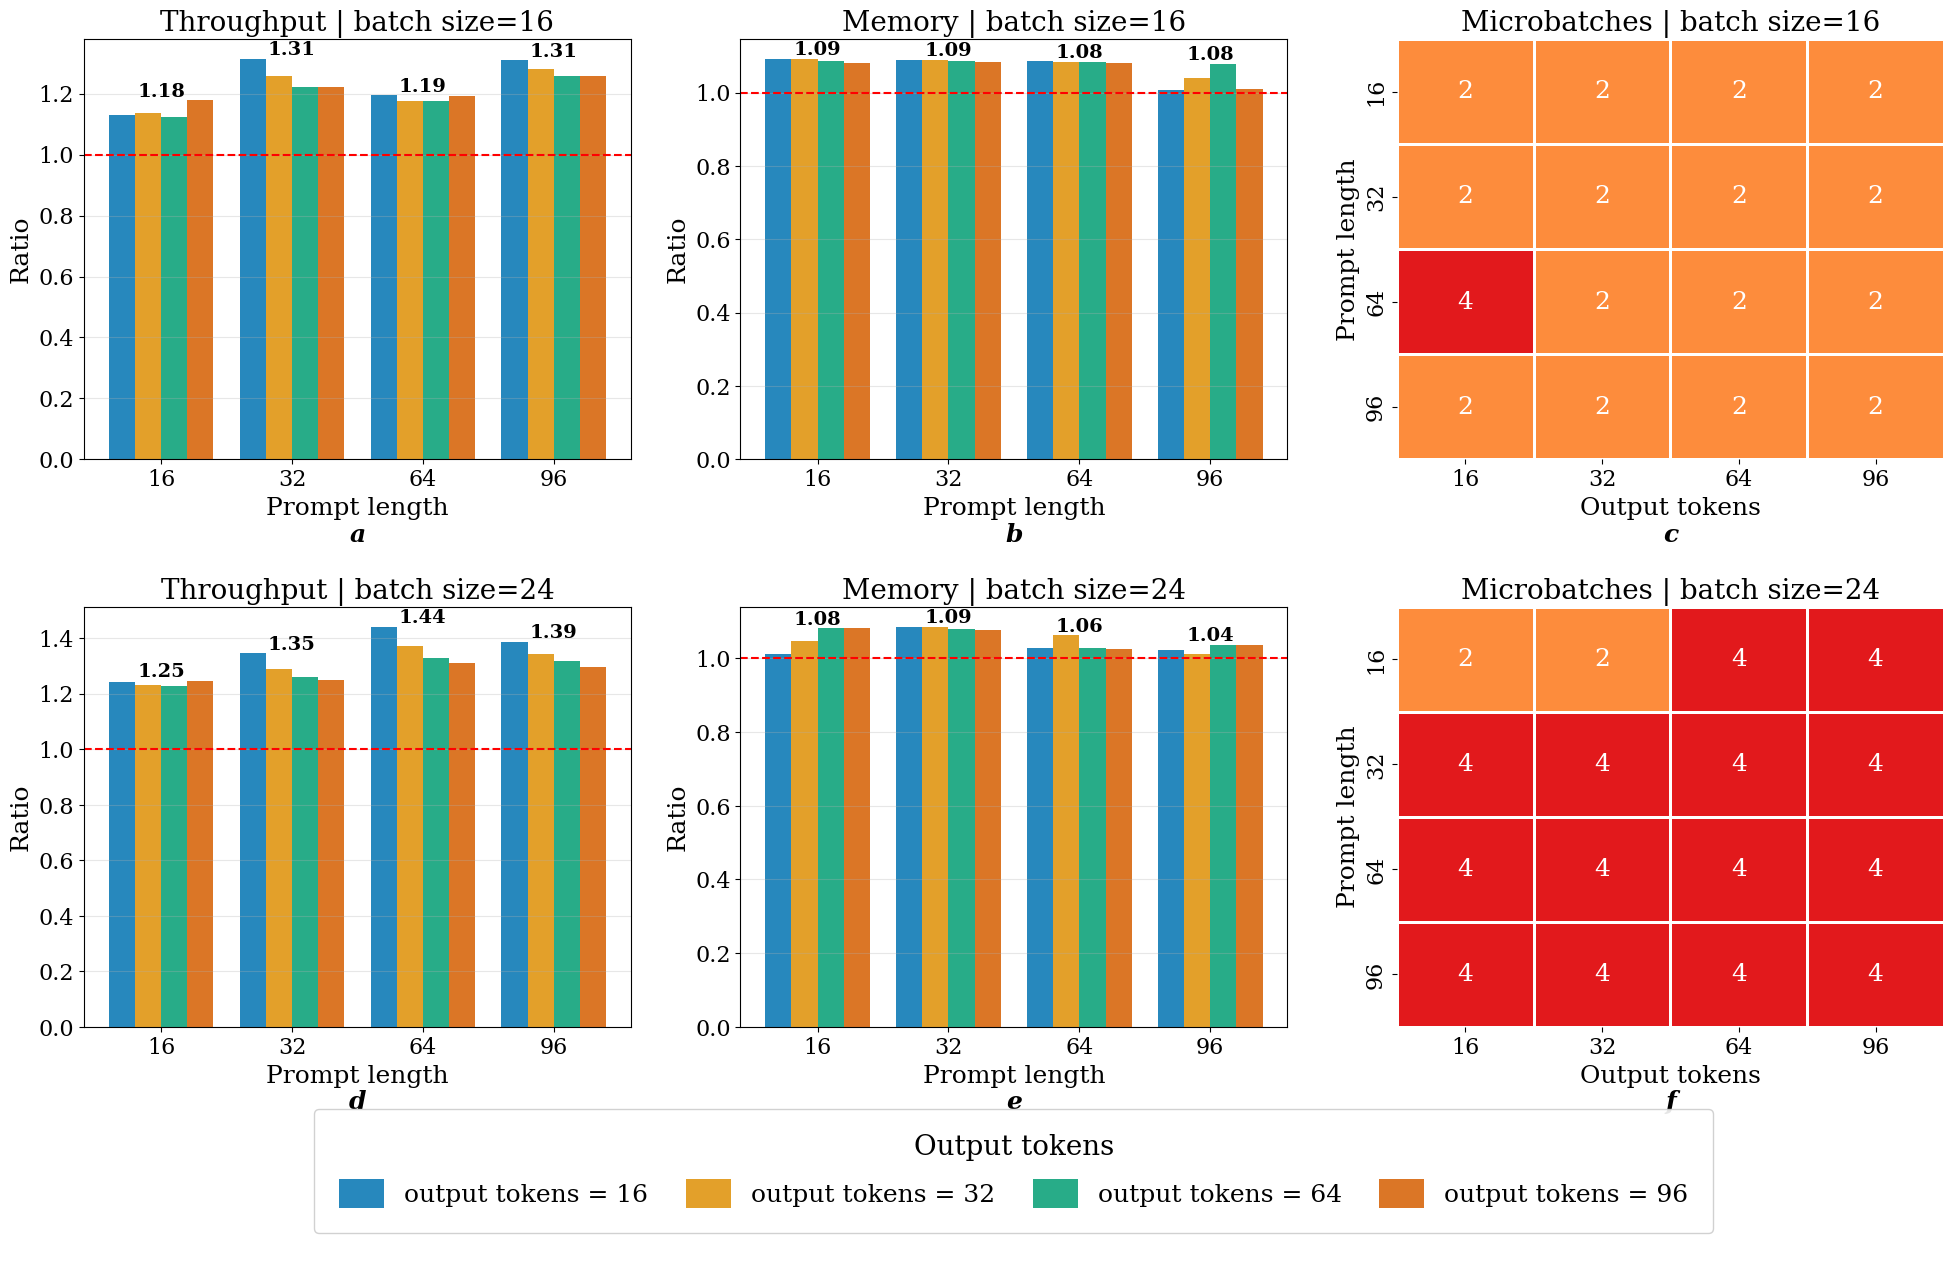

Saved to opt-2.7b.pdf


In [372]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[16, 24],
                             prompt_lens_list=[16, 32, 64, 96],
                             new_tokens_list=[16, 32, 64, 96],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="opt-2.7b.pdf")

## OPT-13B

In [373]:
df_1 = pd.read_csv("src/results/opt/opt-13b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-13b_pipeline_2.csv")

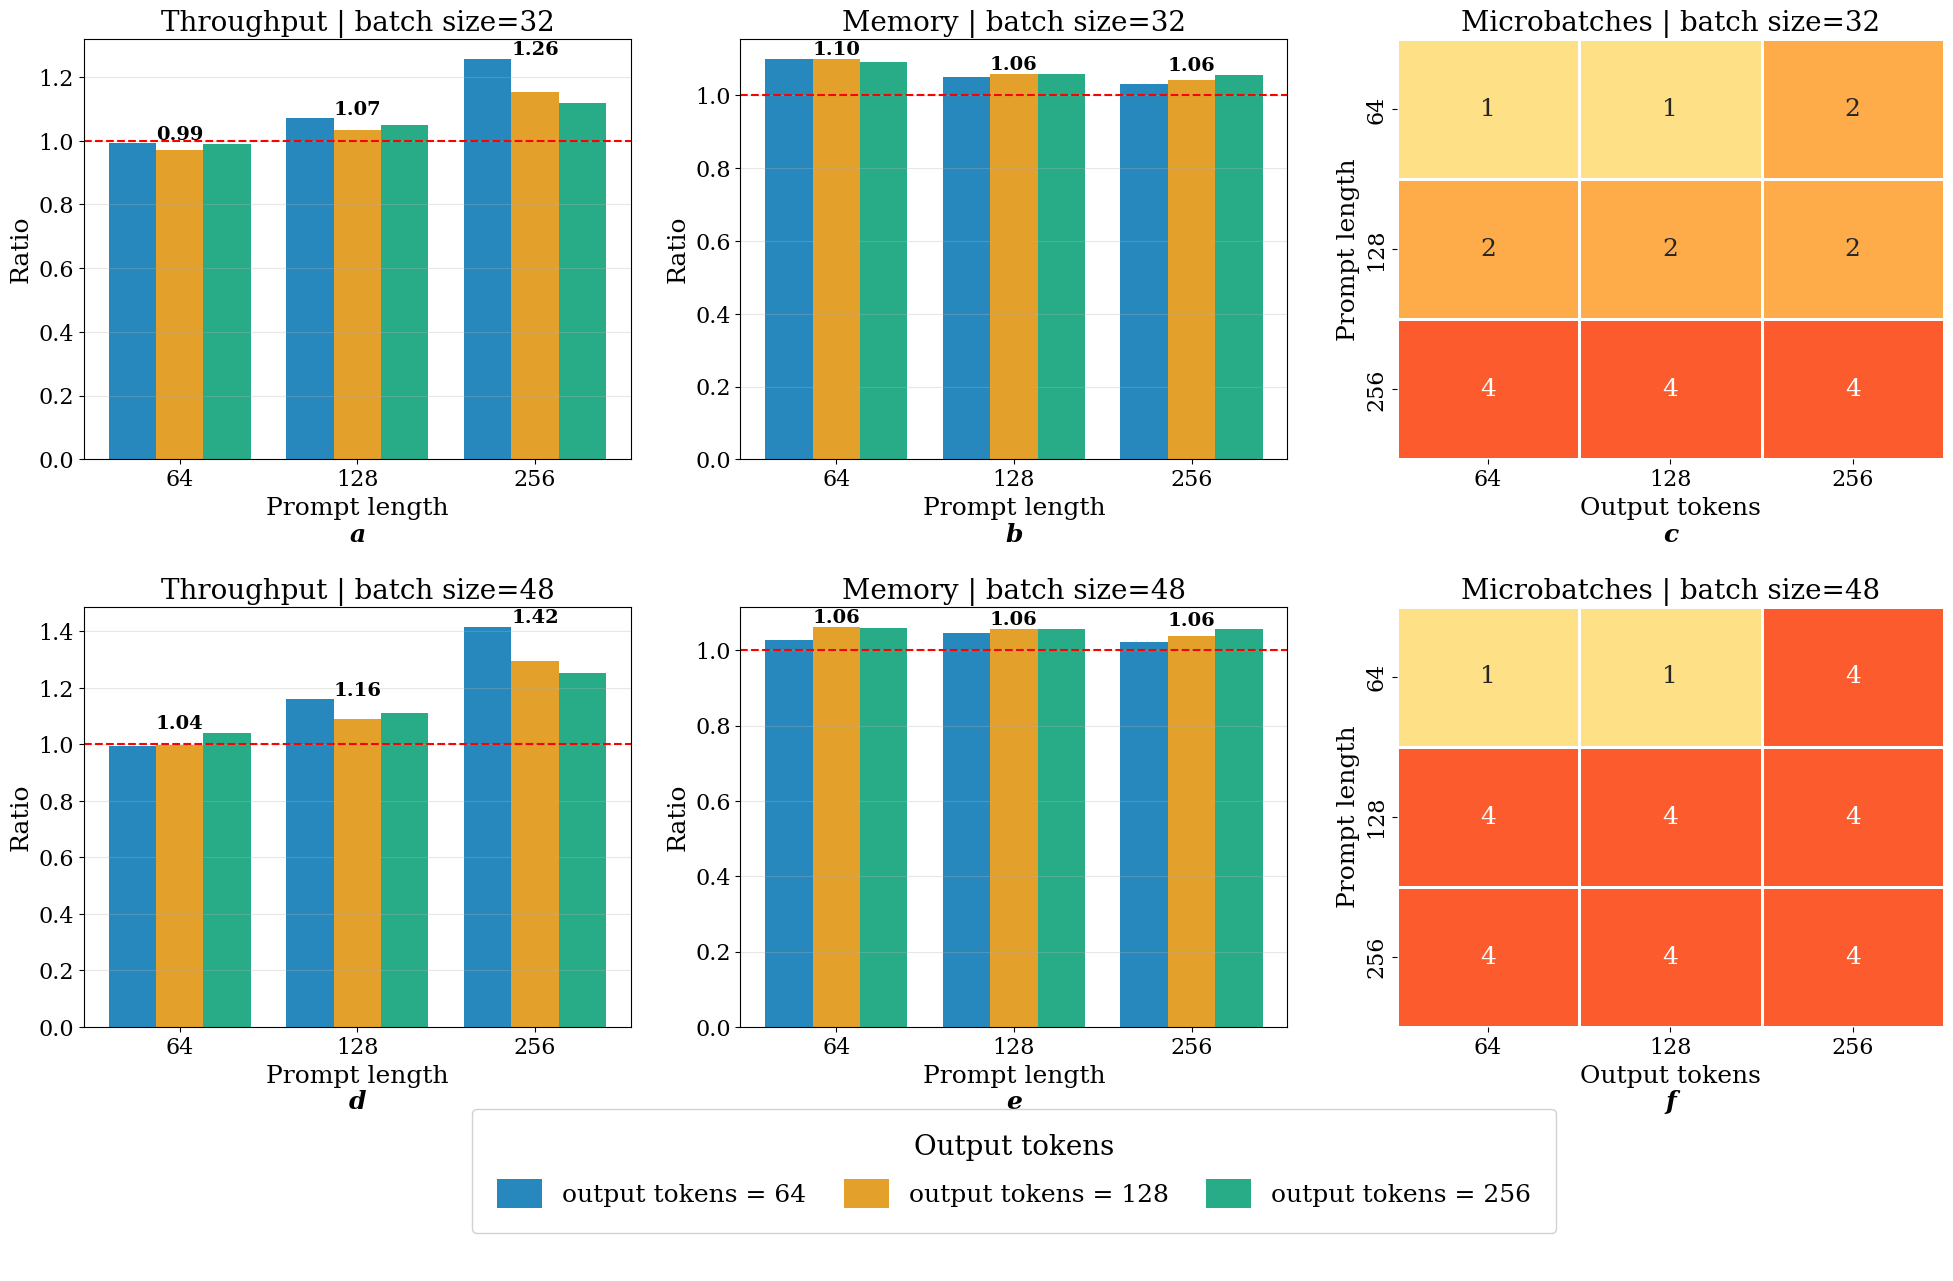

Saved to opt-13b.pdf


In [374]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             batch_sizes=[32, 48],
                             prompt_lens_list=[64, 128, 256],
                             new_tokens_list=[64, 128, 256],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="opt-13b.pdf")

## OPT-6.7B

In [375]:
df_1 = pd.read_csv("src/results/opt/opt-6.7b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-6.7b_pipeline_2.csv")

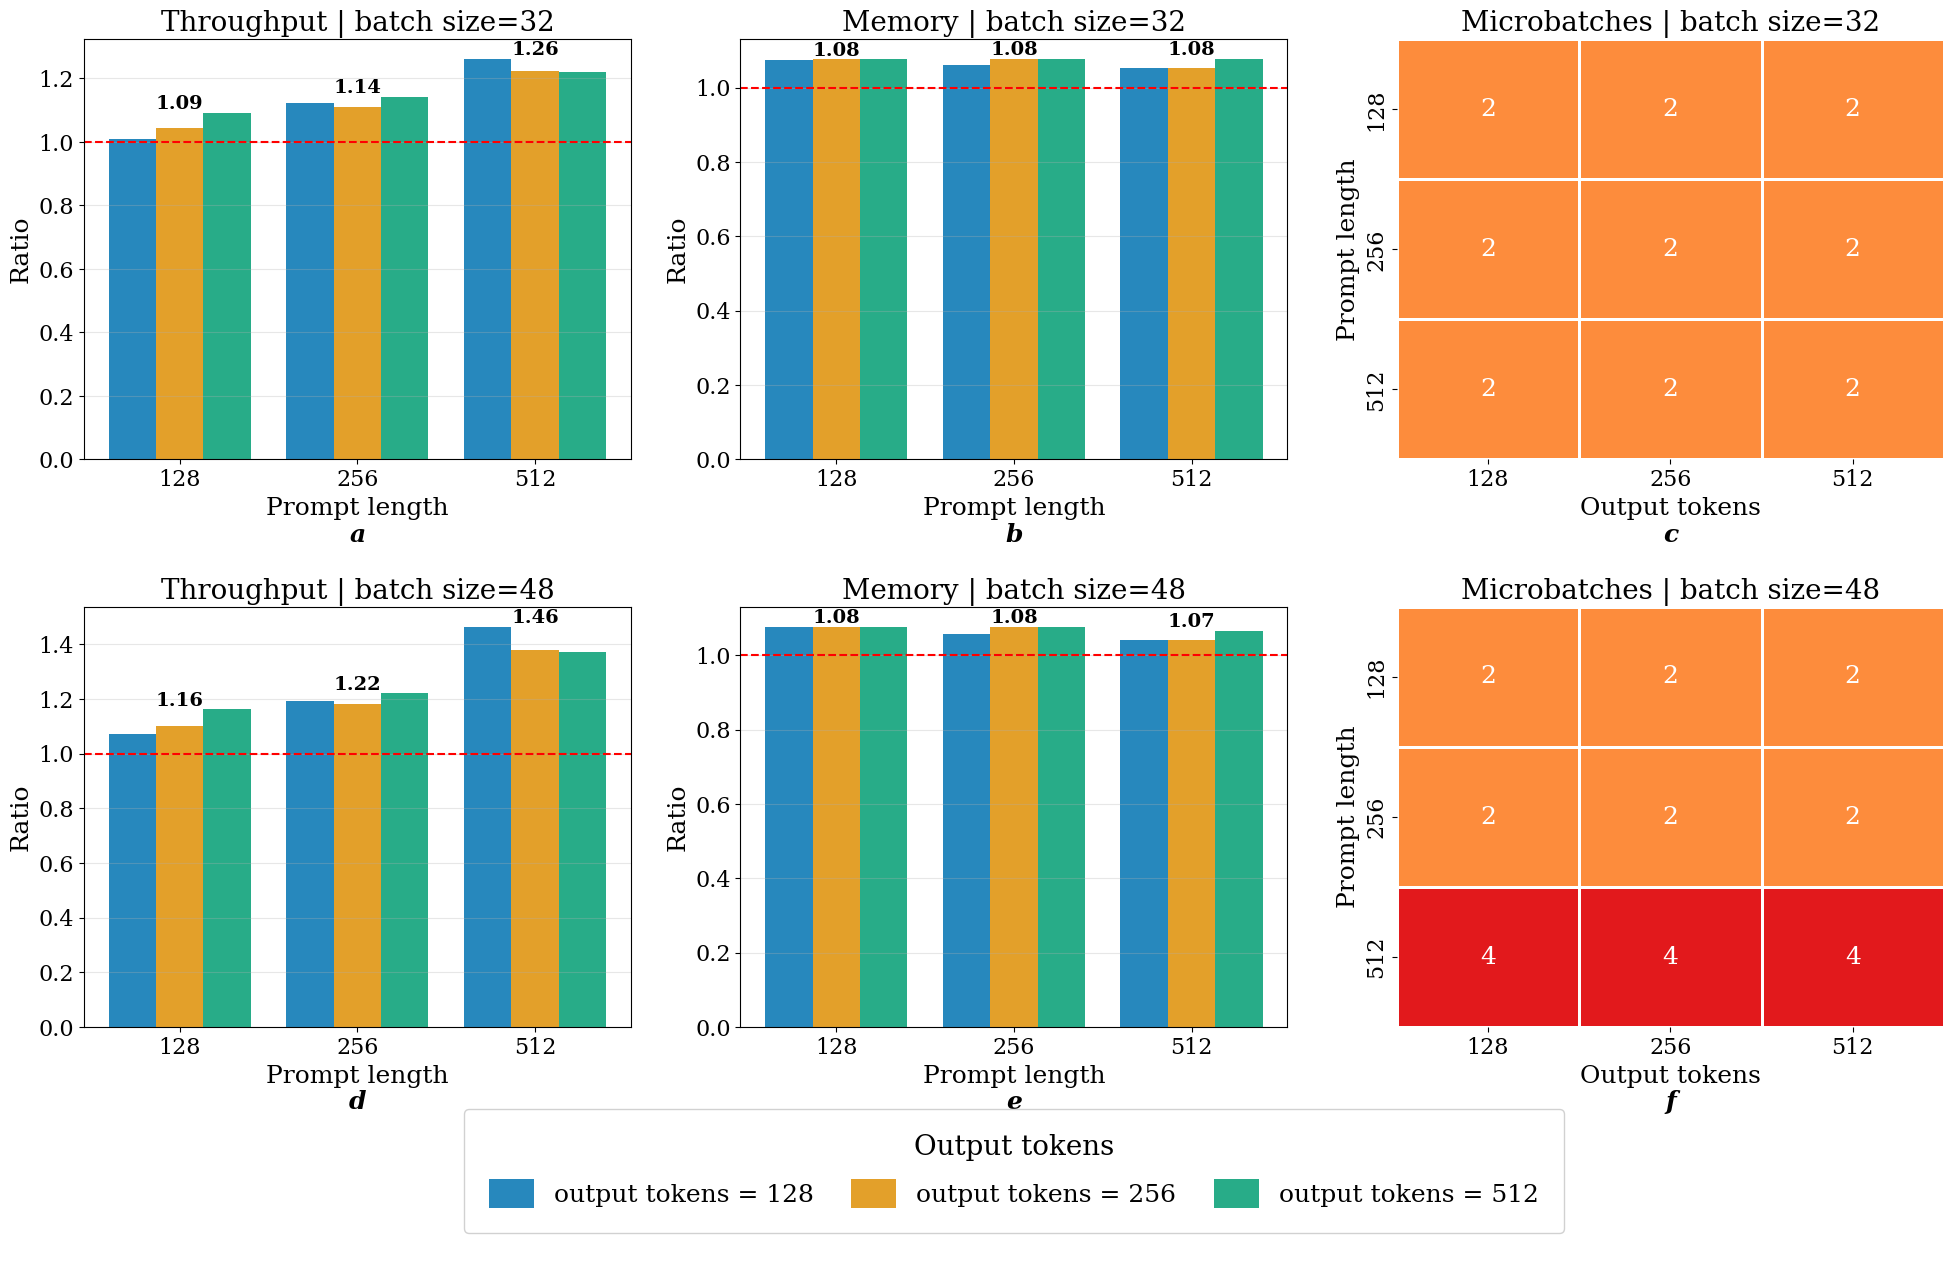

Saved to opt-6.7b.pdf


In [376]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             gpus=['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             batch_sizes=[32, 48],
                             prompt_lens_list=[128, 256, 512],
                             new_tokens_list=[128, 256, 512],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="opt-6.7b.pdf")

## BLOOM-7B1

In [377]:
df_1 = pd.read_csv("src/results/bloom/bloom-7b1_pipeline_1.csv")
df_2 = pd.read_csv("src/results/bloom/bloom-7b1_pipeline_2.csv")

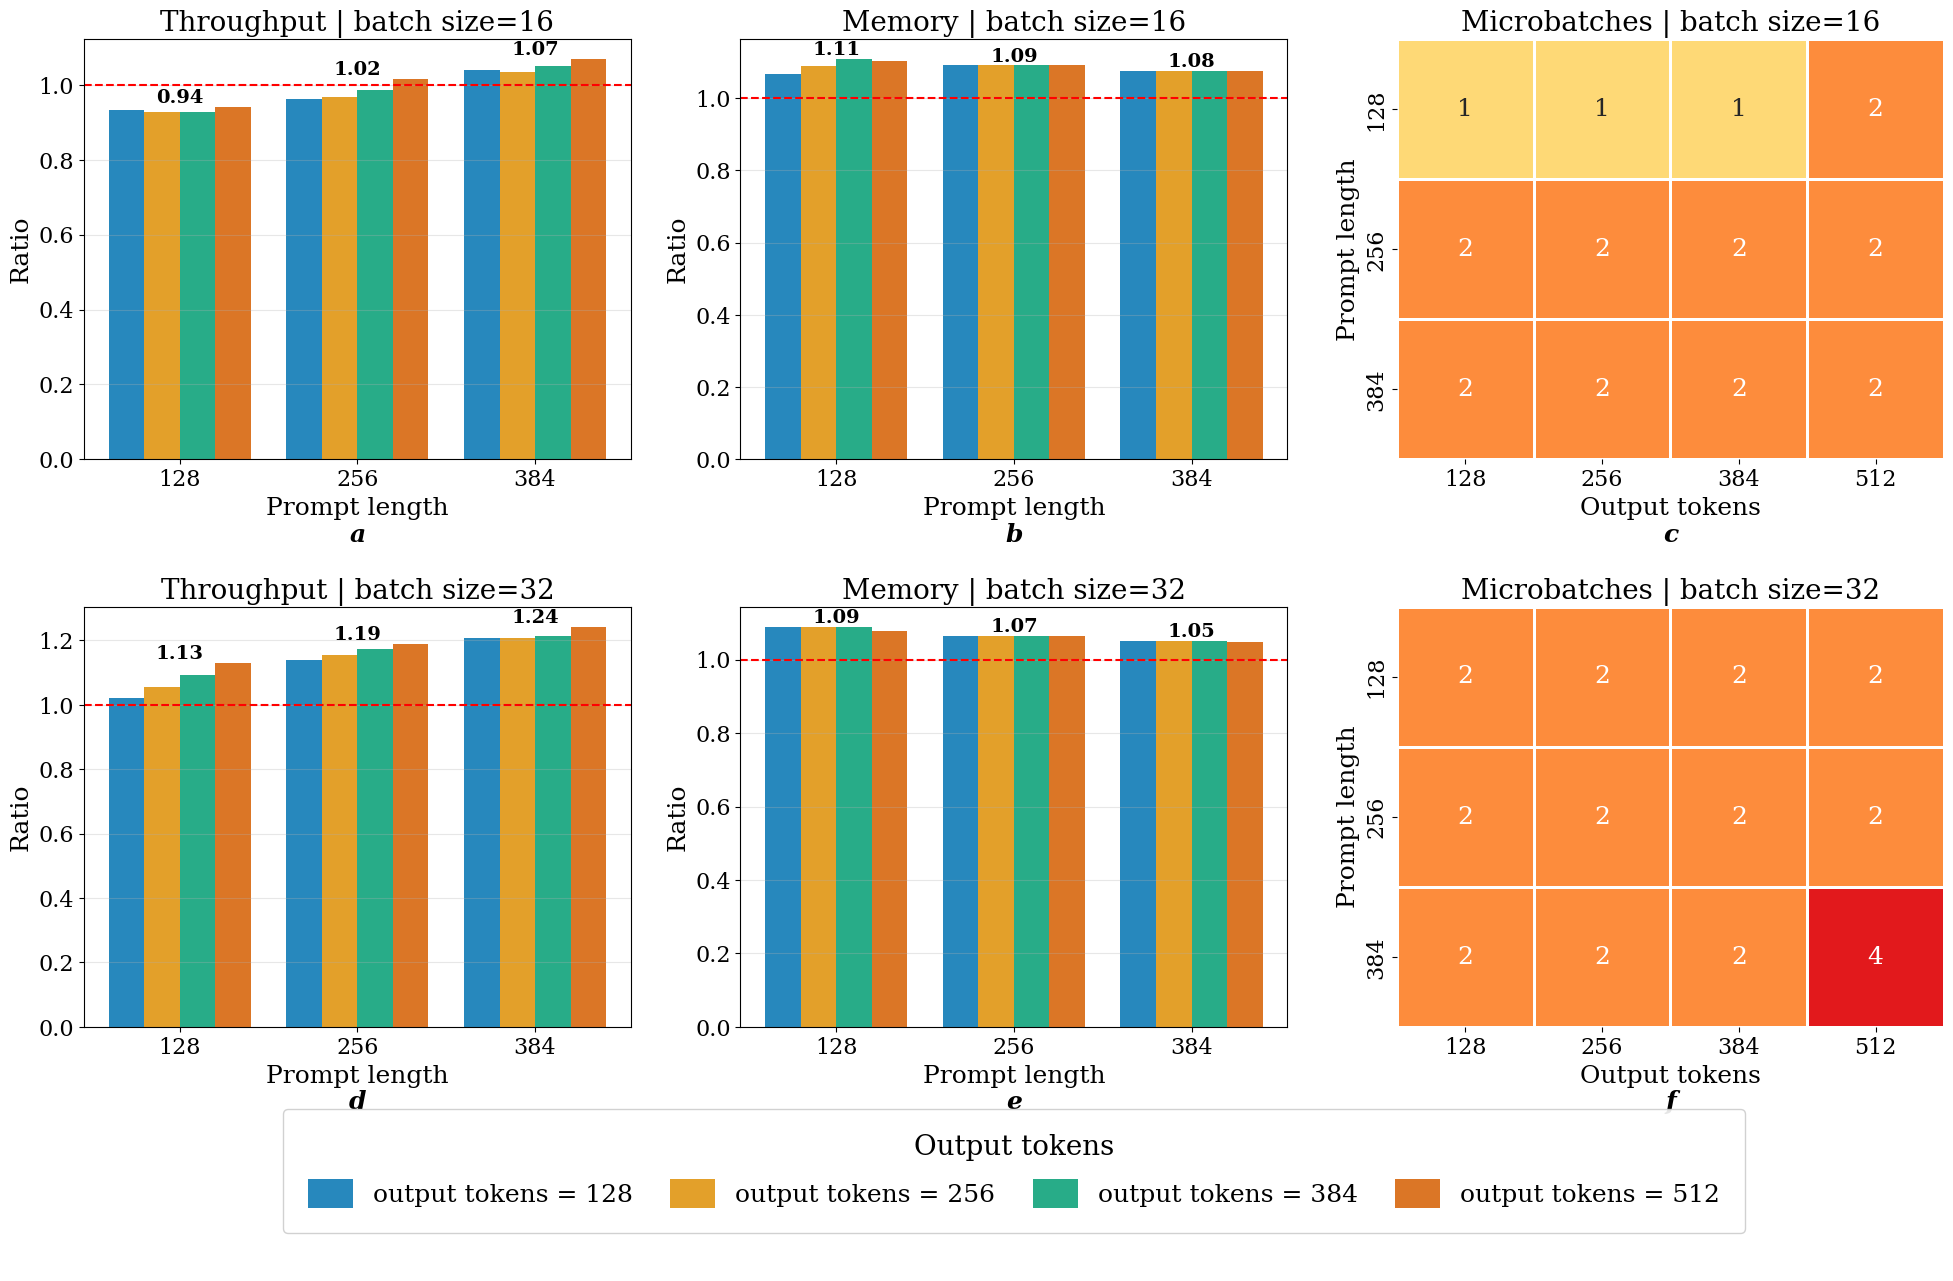

Saved to bloom-7b1.pdf


In [378]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             gpus=['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             batch_sizes=[16, 32],
                             prompt_lens_list=[128, 256, 384],
                             new_tokens_list=[128, 256, 384, 512],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="bloom-7b1.pdf")

## internVIT-6b

In [379]:
df_1 = pd.read_csv("src/results/intern/intern-6b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/intern/intern-6b_pipeline_2.csv")

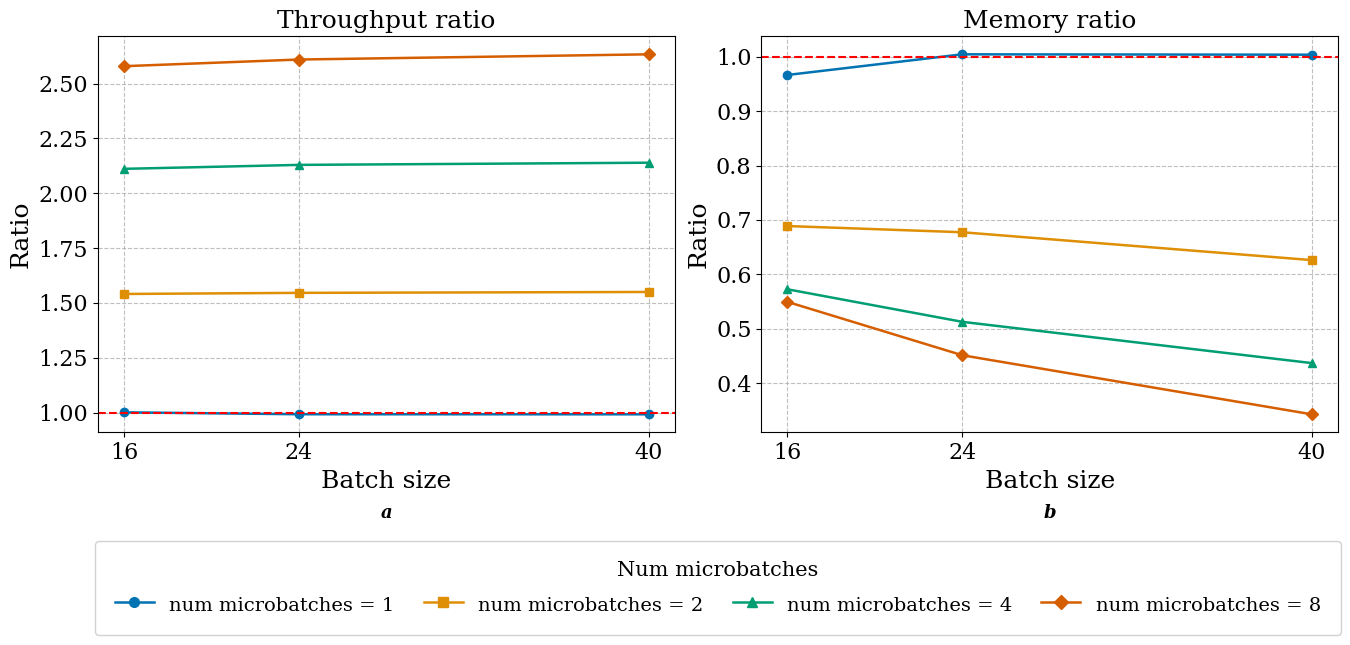

Saved to intern.pdf


In [380]:
plot_ratios_and_microbatches_vit(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             figsize_per_row=7,
                             save_path="intern.pdf")